In [5]:
import pandas as pd

df = pd.read_csv("../AmesHousing.csv")

train_df = df.sample(frac=0.8, random_state=42)


test_df = df.drop(train_df.index)

print("Training data:", train_df.shape)
print("Test data:", test_df.shape)

Training data: (2344, 82)
Test data: (586, 82)


In [6]:
print(train_df.columns.tolist())

['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck 

In [7]:
X_train = train_df.drop(columns=["SalePrice", "Order", "PID"])
y_train = train_df["SalePrice"]

X_test = test_df.drop(columns=["SalePrice", "Order", "PID"])
y_test = test_df["SalePrice"]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2344, 79) (2344,)
(586, 79) (586,)


In [8]:
X_train.isna().sum()

MS SubClass         0
MS Zoning           0
Lot Frontage      394
Lot Area            0
Street              0
                 ... 
Misc Val            0
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
Length: 79, dtype: int64

In [9]:
X_test.isna().sum()

MS SubClass        0
MS Zoning          0
Lot Frontage      96
Lot Area           0
Street             0
                  ..
Misc Val           0
Mo Sold            0
Yr Sold            0
Sale Type          0
Sale Condition     0
Length: 79, dtype: int64

In [10]:
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

X_train = X_train.fillna("None")
X_test = X_test.fillna("None")


In [11]:
X_train["MS SubClass"] = X_train["MS SubClass"].astype(str)
X_test["MS SubClass"] = X_test["MS SubClass"].astype(str)

In [12]:
num_cols = X_train.select_dtypes("number").columns
means = X_train[num_cols].mean()
stds = X_train[num_cols].std().replace(0, 1)

X_train[num_cols] = (X_train[num_cols] - means) / stds
X_test[num_cols] = (X_test[num_cols] - means) / stds

In [13]:
X_train = pd.get_dummies(X_train, dtype=int)
X_test = pd.get_dummies(X_test, dtype=int)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [14]:
print(X_train.shape, X_test.shape)

(2344, 330) (586, 330)


In [ ]:
# Calculate correlation between every training feature and SalePrice
correlations = X_train.corrwith(y_train)

# Remove any NaN correlations, for example from constant columns
correlations = correlations.dropna()

# Sort by absolute correlation strength
sorted_features = correlations.abs().sort_values(ascending=False)

# Keep the original positive/negative correlation values
correlations_sorted = correlations.loc[sorted_features.index]

print(correlations_sorted.head(40))

Overall Qual              0.800899
Gr Liv Area               0.708011
Garage Cars               0.644341
Garage Area               0.636100
Total Bsmt SF             0.628642
1st Flr SF                0.622572
Bsmt Qual_Ex              0.604608
Exter Qual_TA            -0.600075
Year Built                0.565191
Kitchen Qual_Ex           0.552975
Full Bath                 0.550182
Kitchen Qual_TA          -0.534700
Year Remod/Add            0.532479
Foundation_PConc          0.528599
Garage Yr Blt             0.517895
Mas Vnr Area              0.506701
TotRms AbvGrd             0.500629
Exter Qual_Ex             0.481365
Fireplace Qu_None        -0.476589
Fireplaces                0.466477
Heating QC_Ex             0.466418
BsmtFin Type 1_GLQ        0.464112
Bsmt Qual_TA             -0.454907
Exter Qual_Gd             0.454258
BsmtFin SF 1              0.436995
Garage Finish_Unf        -0.432475
Garage Finish_Fin         0.430632
Neighborhood_NridgHt      0.429454
Mas Vnr Type_None   

In [30]:
weak_features = correlations[
    correlations.abs() < 0.05
].sort_values()

print(weak_features.to_string())

MS SubClass_85          -0.049268
Heating_Grav            -0.048809
MS Zoning_A (agr)       -0.048327
Condition 1_RRAe        -0.047654
Heating QC_Po           -0.047334
Exterior 1st_Stucco     -0.046842
Exterior 1st_Plywood    -0.045929
Exterior 2nd_Brk Cmn    -0.045889
Sale Type_Oth           -0.045137
BsmtFin Type 2_BLQ      -0.044431
Sale Condition_Alloca   -0.043049
Sale Type_ConLw         -0.042847
House Style_SLvl        -0.042360
Roof Style_Gambrel      -0.042197
Condition 2_Feedr       -0.042137
Fence_MnWw              -0.041598
Neighborhood_NPkVill    -0.040764
Neighborhood_Mitchel    -0.040725
Garage Qual_Po          -0.038721
Condition 2_Norm        -0.038290
Electrical_FuseP        -0.038117
Sale Condition_Family   -0.037900
Functional_Maj1         -0.036703
MS SubClass_80          -0.036642
BsmtFin Type 2_LwQ      -0.036611
MS Zoning_I (all)       -0.036415
Low Qual Fin SF         -0.035896
Bsmt Qual_Po            -0.034742
Exter Cond_Po           -0.034345
Utilities_NoSe

Correlation analysis showed that features such as Overall Quality, Above Ground Living Area, Garage Cars, Garage Area and Total Basement Area had strong relationships with SalePrice. Several encoded categorical levels showed weak individual correlations. However, these levels belong to larger categorical variables and a weak Pearson correlation does not necessarily mean that the feature is not useful, particularly for the Decision Tree and Random Forest models. Therefore, features were not removed solely based on a correlation threshold. Order and PID were removed because they are identifiers rather than meaningful house characteristics.

In [31]:
top_features = correlations_sorted.head(15)

top_features_df = pd.DataFrame({
    "Feature": top_features.index,
    "Correlation with SalePrice": top_features.values
})

top_features_df

,Feature,Correlation with SalePrice
0,Overall Qual,0.800899
1,Gr Liv Area,0.708011
2,Garage Cars,0.644341
3,Garage Area,0.636100
4,Total Bsmt SF,0.628642
5,1st Flr SF,0.622572
6,Bsmt Qual_Ex,0.604608
7,Exter Qual_TA,-0.600075
8,Year Built,0.565191
9,Kitchen Qual_Ex,0.552975


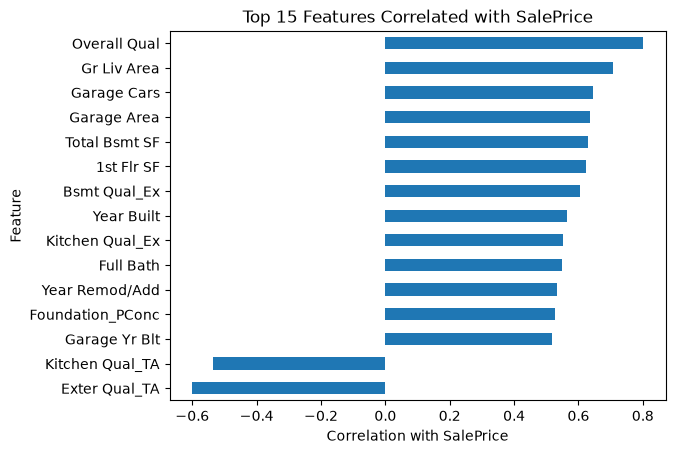

In [32]:
import matplotlib.pyplot as plt

top_features.sort_values().plot(kind="barh")

plt.xlabel("Correlation with SalePrice")
plt.ylabel("Feature")
plt.title("Top 15 Features Correlated with SalePrice")
plt.show()